# **Step 1: Set Up & Data Loading**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
df = pd.read_csv("/content/CLEANED_marketing_campaign_dataset.csv", on_bad_lines='skip')

# Data Cleaning: Essential for T-Tests as they are sensitive to NaNs
df = df.dropna(subset=['acquisition_cost', 'roi_ratio'])

# **Step 2: Segmenting the Data**

In [7]:
# Calculate the median spend
median_spend = df["acquisition_cost"].median()

# Create two groups
# The "Double Bracket" or "Loc" method is often seen as more professional
high_budget = df.loc[df["acquisition_cost"] > median_spend, "roi_ratio"]
low_budget  = df.loc[df["acquisition_cost"] <= median_spend, "roi_ratio"]

print(f"Median Spend Threshold: ${median_spend:,.2f}")
print(f"High Budget Count: {len(high_budget)}")
print(f"Low Budget Count: {len(low_budget)}")
print(f"High Budget Mean ROI: {high_budget.mean():,.2f}")

Median Spend Threshold: $12,496.50
High Budget Count: 100000
Low Budget Count: 100000
High Budget Mean ROI: 1.57


# **Step 3: The T-Test Implementation**

In [8]:
# Perform Welch's T-Test
t_stat, p_value = stats.ttest_ind(high_budget, low_budget, equal_var=False)

# Calculate the Means for context
mean_high = high_budget.mean()
mean_low = low_budget.mean()

print(f"--- T-Test Results ---")
print(f"Mean ROI (High Budget): {mean_high:.4f}")
print(f"Mean ROI (Low Budget): {mean_low:.4f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value}")

--- T-Test Results ---
Mean ROI (High Budget): 1.5689
Mean ROI (Low Budget): 4.0466
T-Statistic: -160.9957
P-Value: 0.0


# **Step 4: Visualizing the "Difference"**

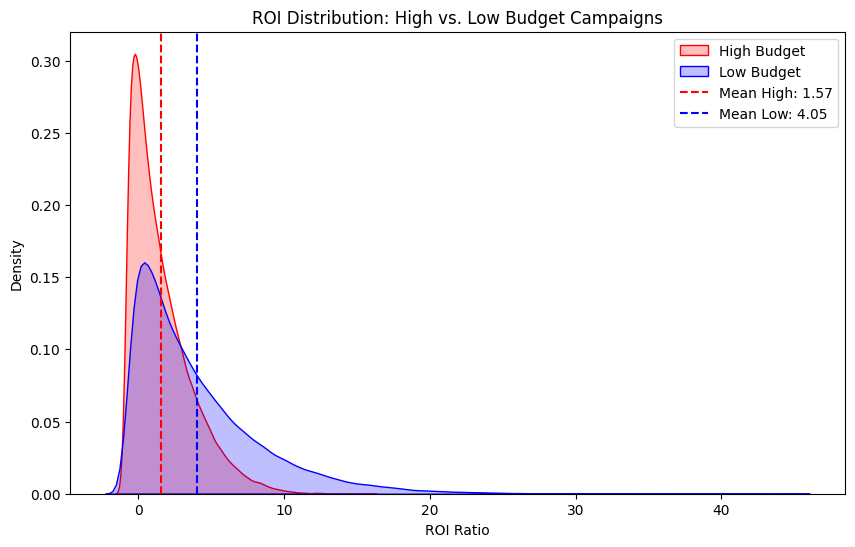

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(high_budget, label="High Budget", fill=True, color='red')
sns.kdeplot(low_budget, label="Low Budget", fill=True, color='blue')
plt.axvline(mean_high, color='red', linestyle='--', label=f'Mean High: {mean_high:.2f}')
plt.axvline(mean_low, color='blue', linestyle='--', label=f'Mean Low: {mean_low:.2f}')

plt.title("ROI Distribution: High vs. Low Budget Campaigns")
plt.xlabel("ROI Ratio")
plt.ylabel("Density")
plt.legend()
plt.show()

# Based on the generated plot and the T-test results, here are the key insights:

**Lower ROI for High-Budget Campaigns:** The visualization clearly shows that the distribution of Return on Investment (ROI) for 'High Budget' campaigns is centered around a significantly lower value (Mean ROI: 1.57) compared to 'Low Budget' campaigns.

**Higher ROI for Low-Budget Campaigns:** Conversely, 'Low Budget' campaigns exhibit an ROI distribution that is shifted to the right, indicating a higher average ROI (Mean ROI: 4.05).

**Statistical Significance:** The T-statistic of -160.9957 and a P-value of 0.0 strongly suggest that this difference in ROI between high and low budget campaigns is highly statistically significant. This means it's extremely unlikely that the observed difference is due to random chance.

In summary, **despite investing more, high-budget campaigns are generating a substantially lower ROI than low-budget campaigns. This finding suggests that simply increasing the budget does not guarantee better returns, and there might be inefficiencies or different strategies at play in higher-spending campaigns that warrant further investigation.**